# Detecção de Anomalias em Gastos Municipais do Paraná

Pipeline em 7 passos sobre os 399 municípios do PR (2020–2025), usando
**Despesas por Função** (DCA-Anexo I-E) do SICONFI e estimativas de
população do IBGE (SIDRA tab. 6579).

| Passo | O que faz |
|---|---|
| 1 | Imports |
| 2 | Carregar FINBRA + IBGE → painel município-ano |
| 3 | Limpar declarações ruins |
| 4 | **Features** (per capita + proporção + variação + cluster) |
| 5 | Normalizar (RobustScaler) |
| 6 | **Detectar** (Isolation Forest + LOF) |
| 7 | **Ranking + descrição** das anomalias |
| 8 | Exportar |



## 1 — Imports



In [172]:
import warnings, re, hashlib
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.impute import SimpleImputer

DATA_DIR    = Path('data')
EXPORTS_DIR = Path('exports')
EXPORTS_DIR.mkdir(exist_ok=True)

ANOS = [2020, 2021, 2022, 2023, 2024, 2025]
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

FUNCOES = {
    '01':'legislativa','02':'judiciaria','03':'essencial_justica','04':'administracao',
    '05':'defesa_nacional','06':'seguranca_publica','07':'relacoes_exteriores',
    '08':'assistencia_social','09':'previdencia_social','10':'saude','11':'trabalho',
    '12':'educacao','13':'cultura','14':'direitos_cidadania','15':'urbanismo',
    '16':'habitacao','17':'saneamento','18':'gestao_ambiental','19':'ciencia_tecnologia',
    '20':'agricultura','21':'organizacao_agraria','22':'industria','23':'comercio_servicos',
    '24':'comunicacoes','25':'energia','26':'transporte','27':'desporto_lazer',
    '28':'encargos_especiais','99':'reserva_contingencia',
}
COL_FUNCOES = list(FUNCOES.values())

plt.rcParams['figure.dpi']  = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size']   = 10

print('Setup ok.')



Setup ok.


In [154]:
# Rotulos amigaveis para tornar graficos e impressoes legiveis.
LABELS_FUNCAO = {
    'legislativa':          'Legislativa',
    'judiciaria':           'Judiciaria',
    'essencial_justica':    'Essencial a Justica',
    'administracao':        'Administracao',
    'defesa_nacional':      'Defesa Nacional',
    'seguranca_publica':    'Seguranca Publica',
    'relacoes_exteriores':  'Relacoes Exteriores',
    'assistencia_social':   'Assistencia Social',
    'previdencia_social':   'Previdencia Social',
    'saude':                'Saude',
    'trabalho':             'Trabalho',
    'educacao':             'Educacao',
    'cultura':              'Cultura',
    'direitos_cidadania':   'Direitos da Cidadania',
    'urbanismo':            'Urbanismo',
    'habitacao':            'Habitacao',
    'saneamento':           'Saneamento',
    'gestao_ambiental':     'Gestao Ambiental',
    'ciencia_tecnologia':   'Ciencia e Tecnologia',
    'agricultura':          'Agricultura',
    'organizacao_agraria':  'Organizacao Agraria',
    'industria':            'Industria',
    'comercio_servicos':    'Comercio e Servicos',
    'comunicacoes':         'Comunicacoes',
    'energia':              'Energia',
    'transporte':           'Transporte',
    'desporto_lazer':       'Desporto e Lazer',
    'encargos_especiais':   'Encargos Especiais',
    'reserva_contingencia': 'Reserva de Contingencia',
}

LABELS_SUFIXO = {
    '_pc':   'R$ por habitante',
    '_prop': '% do gasto total',
    '_var':  'variacao ano-a-ano',
    '_dev':  'desvio do cluster',
}

LABELS_CONTEXTO = {
    'log_pop':         'Porte populacional (log)',
    'log_pop_cl':      'Porte populacional (log)',
    'log_total_pc_cl': 'Gasto per capita total (log)',
    'hhi':             'Concentracao do gasto (HHI)',
}


def pretty(feat: str) -> str:
    """Traduz nome tecnico de feature em rotulo legivel."""
    if feat in LABELS_CONTEXTO:
        return LABELS_CONTEXTO[feat]
    for suf, label in LABELS_SUFIXO.items():
        if feat.endswith(suf):
            base = feat[:-len(suf)]
            nome = LABELS_FUNCAO.get(base, base.replace('_', ' ').title())
            return f'{nome} ({label})'
    return LABELS_FUNCAO.get(feat, feat.replace('_', ' ').title())


# Teste rapido
print('Exemplos de rotulos:')
for f in ['saude_pc', 'habitacao_prop', 'educacao_var',
          'saude_dev', 'log_pop', 'hhi']:
    print(f'  {f:25s} -> {pretty(f)}')



Exemplos de rotulos:
  saude_pc                  -> Saude (R$ por habitante)
  habitacao_prop            -> Habitacao (% do gasto total)
  educacao_var              -> Educacao (variacao ano-a-ano)
  saude_dev                 -> Saude (desvio do cluster)
  log_pop                   -> Porte populacional (log)
  hhi                       -> Concentracao do gasto (HHI)


## 2 — Carregamento

Lê 6 CSVs FINBRA (formato long, separador `;`, encoding latin-1, decimal
vírgula, 3 linhas de metadata no topo) e o CSV do IBGE. Resultado: painel
`município-ano` com 29 colunas de função + população.



In [155]:
RE_TOP = re.compile(r'^\s*(\d{2})\s*-\s*(.+)$')
RE_SUB = re.compile(r'^\s*\d{2}\.\d{3}')

def _parse_valor_br(s):
    return pd.to_numeric(
        s.astype(str).str.strip()
         .str.replace('.', '', regex=False)
         .str.replace(',', '.', regex=False),
        errors='coerce')

def carregar_finbra(path, ano):
    df = None
    for enc in ['latin-1', 'cp1252', 'utf-8-sig', 'utf-8']:
        try:
            df = pd.read_csv(path, sep=';', encoding=enc, skiprows=3,
                             dtype=str, engine='python')
            df.columns = [str(c).strip().lstrip('\ufeff') for c in df.columns]
            if {'Cod.IBGE', 'Conta', 'Valor'}.issubset(set(df.columns)):
                break
        except Exception:
            df = None
    if df is None:
        raise RuntimeError(f'Nao consegui ler {path}')

    df = df[df['Coluna'].astype(str).str.strip() == 'Despesas Empenhadas'].copy()
    df['Conta'] = df['Conta'].astype(str).str.strip()
    df = df[~df['Conta'].str.contains('Exceto', case=False, na=False)]
    df = df[~df['Conta'].str.match(RE_SUB)]
    m = df['Conta'].str.extract(RE_TOP)
    df['cod_funcao'] = m[0]
    df = df[df['cod_funcao'].notna() & df['cod_funcao'].isin(FUNCOES.keys())]
    df['nome_funcao'] = df['cod_funcao'].map(FUNCOES)
    df['Valor'] = _parse_valor_br(df['Valor'])
    df = df.dropna(subset=['Valor'])
    df['Cod.IBGE'] = (df['Cod.IBGE'].astype(str).str.strip()
                       .str.replace('.', '', regex=False))
    df = df[df['Cod.IBGE'].str.fullmatch(r'41\d{5}')]
    df['cod_ibge'] = df['Cod.IBGE'].astype(int)
    df['municipio'] = (df['Instituição'].astype(str).str.strip()
                       .str.replace(r'\s*-\s*PR\s*$', '', regex=True)
                       .str.replace(r'^Prefeitura Municipal de\s+', '', regex=True))
    df['ano'] = ano
    return df[['cod_ibge', 'municipio', 'ano', 'nome_funcao', 'Valor']]


hashes = {}
for ano in ANOS:
    p = DATA_DIR / f'finbra_dca_ie_PR_{ano}.csv'
    if p.exists():
        h = hashlib.md5(p.read_bytes()).hexdigest()
        if h in hashes:
            print(f'  [AVISO] {p.name} e identico a {hashes[h]} — refazer download')
        hashes[h] = p.name

partes = []
for ano in ANOS:
    p = DATA_DIR / f'finbra_dca_ie_PR_{ano}.csv'
    if not p.exists():
        continue
    d = carregar_finbra(p, ano)
    partes.append(d)
    print(f'  {p.name}: {len(d):,} linhas · {d["cod_ibge"].nunique()} municipios')
finbra = pd.concat(partes, ignore_index=True)
print(f'\nTotal: {len(finbra):,} linhas · {finbra["cod_ibge"].nunique()} municipios')



  finbra_dca_ie_PR_2020.csv: 5,965 linhas · 399 municipios
  finbra_dca_ie_PR_2021.csv: 5,975 linhas · 399 municipios
  finbra_dca_ie_PR_2022.csv: 6,120 linhas · 398 municipios
  finbra_dca_ie_PR_2023.csv: 6,163 linhas · 398 municipios
  finbra_dca_ie_PR_2024.csv: 6,173 linhas · 396 municipios
  finbra_dca_ie_PR_2025.csv: 3,757 linhas · 241 municipios

Total: 34,153 linhas · 399 municipios


In [156]:
def carregar_ibge(path):
    df = None
    for enc in ['utf-8', 'utf-8-sig', 'latin-1', 'cp1252']:
        try:
            tmp = pd.read_csv(path, sep=';', encoding=enc, skiprows=3,
                              dtype=str, engine='python')
            tmp.columns = [str(c).strip().lstrip('\ufeff') for c in tmp.columns]
            if any(re.fullmatch(r'\d{4}', c) for c in tmp.columns):
                df = tmp; break
        except Exception:
            continue
    if df is None:
        raise RuntimeError(f'Nao consegui ler {path}')

    mun = df.columns[0]
    ano_cols = [c for c in df.columns if re.fullmatch(r'\d{4}', c)]
    df = df[[mun] + ano_cols].rename(columns={mun: 'municipio_ibge'})
    df = df.dropna(subset=['municipio_ibge'])
    df = df[df['municipio_ibge'].str.contains(r'\(PR\)$', regex=True)]
    df['municipio_ibge'] = df['municipio_ibge'].str.replace(
        r'\s*\(PR\)\s*$', '', regex=True).str.strip()

    pop = df.melt(id_vars='municipio_ibge', value_vars=ano_cols,
                  var_name='ano', value_name='populacao')
    pop['ano'] = pop['ano'].astype(int)
    pop['populacao'] = pd.to_numeric(
        pop['populacao'].astype(str).str.replace('.', '', regex=False),
        errors='coerce')
    pop = pop.dropna(subset=['populacao'])
    pop['populacao'] = pop['populacao'].astype(int)
    return pop


pop_ibge = carregar_ibge(DATA_DIR / 'populacao_ibge.csv')
print(f'IBGE: {len(pop_ibge):,} linhas · '
      f'{pop_ibge["municipio_ibge"].nunique()} municipios · '
      f'anos: {sorted(pop_ibge["ano"].unique())}')



IBGE: 1,596 linhas · 399 municipios · anos: [np.int64(2020), np.int64(2021), np.int64(2024), np.int64(2025)]


In [157]:
agg = (finbra.groupby(['cod_ibge', 'municipio', 'ano', 'nome_funcao'])['Valor']
             .sum().reset_index())
wide = (agg.pivot_table(index=['cod_ibge', 'municipio', 'ano'],
                        columns='nome_funcao', values='Valor', fill_value=0.0)
          .reset_index())
wide.columns.name = None
for f in COL_FUNCOES:
    if f not in wide.columns:
        wide[f] = 0.0
wide = wide[['cod_ibge', 'municipio', 'ano'] + COL_FUNCOES]
wide['total_despesas'] = wide[COL_FUNCOES].sum(axis=1)

def norm(s):
    return (s.astype(str).str.lower()
             .str.normalize('NFKD').str.encode('ascii', 'ignore').str.decode('ascii')
             .str.strip().str.replace(r'\s+', ' ', regex=True))

wide['_k']     = norm(wide['municipio'])
pop_ibge['_k'] = norm(pop_ibge['municipio_ibge'])
cod_map = wide.groupby('_k')['cod_ibge'].first().to_dict()
pop_ibge['cod_ibge'] = pop_ibge['_k'].map(cod_map)
pop_ibge = pop_ibge.dropna(subset=['cod_ibge']).copy()
pop_ibge['cod_ibge'] = pop_ibge['cod_ibge'].astype(int)

idx = pd.MultiIndex.from_product([pop_ibge['cod_ibge'].unique(), ANOS],
                                  names=['cod_ibge', 'ano'])
pop_full = (pop_ibge[['cod_ibge', 'ano', 'populacao']]
            .set_index(['cod_ibge', 'ano']).reindex(idx).reset_index()
            .sort_values(['cod_ibge', 'ano']))
pop_full['populacao'] = (pop_full.groupby('cod_ibge')['populacao']
                          .transform(lambda s: s.interpolate(method='linear',
                                                             limit_direction='both')))
pop_full['populacao'] = pop_full['populacao'].round().astype('Int64')

raw_df = wide.drop(columns='_k').merge(pop_full, on=['cod_ibge', 'ano'], how='left')
raw_df = raw_df.dropna(subset=['populacao']).copy()
raw_df['populacao'] = raw_df['populacao'].astype(int)

print(f'Painel municipio-ano: {raw_df.shape}')
print(raw_df.groupby('ano').size().rename('n').to_string())



Painel municipio-ano: (2231, 34)
ano
2020    399
2021    399
2022    398
2023    398
2024    396
2025    241


## 3 — Limpeza

Remove linhas com declaração extremamente incompleta (< 3 funções com
valor) — provável erro de declaração, não anomalia real de gasto.



In [158]:
df = raw_df.copy()
n_decl = (df[COL_FUNCOES] > 0).sum(axis=1)
df['n_funcoes_declaradas'] = n_decl
df['flag_negativo'] = (df[COL_FUNCOES] < 0).any(axis=1)
df = df[(n_decl >= 3) & (df['total_despesas'] > 0)].reset_index(drop=True)
print(f'Apos limpeza: {len(df):,} linhas · {df["cod_ibge"].nunique()} municipios')



Apos limpeza: 2,226 linhas · 399 municipios


## 4 — Features

Esta é a etapa principal. Sem rótulos de "fraude", a qualidade da
detecção depende das features escolhidas. Construímos **5 famílias**
que respondem a perguntas diferentes sobre o gasto:

| Família | Pergunta | Como funciona |
|---|---|---|
| **Per capita** | Gastou muito ou pouco em valor absoluto? | `valor / população` |
| **Proporção** | Como distribuiu o orçamento? | `valor / total` |
| **Variação** | Mudou bruscamente vs ano anterior? | Δ% ano-a-ano |
| **Cluster** | Como se compara com cidades parecidas? | Agrupa cidades similares e mede desvio |
| **Contexto** | Porte e concentração geral | log_pop, HHI |

A família **Cluster** é a chave. Cidades de portes/perfis muito diferentes
não deveriam ser comparadas diretamente — Curitiba e uma cidade de 2 mil
habitantes têm dinâmicas distintas. Antes de criar features comparativas,
agrupamos as cidades em "famílias" parecidas e medimos quanto cada uma
desvia da sua família.



#### Glossário rápido dos sufixos

Para tornar a leitura dos gráficos mais simples, cada feature segue um padrão:

| Sufixo | Significado | Exemplo |
|---|---|---|
| `_pc` | Valor em R$ por habitante | `saude_pc` = R$ gastos em saúde por habitante |
| `_prop` | Proporção do gasto total (0 a 1) | `saude_prop` = 0,30 → 30% do orçamento em saúde |
| `_var` | Variação percentual vs ano anterior | `saude_var` = 0,5 → cresceu 50% |
| `_dev` | Desvio da mediana do cluster, em IQRs | `saude_dev` = +3 → 3 IQRs acima do grupo |

Os gráficos a seguir já mostram esses rótulos em formato legível
("Saúde (R$ por habitante)" em vez de `saude_pc`).



### 4.1 — Per capita (`*_pc`)

> Pergunta: **Gastou muito ou pouco?**

Divide o gasto absoluto pela população. Sem essa normalização, Curitiba
domina toda análise só por ser grande. O gráfico abaixo mostra a
distribuição em três funções centrais — **note as caudas longas**: a
maioria dos municípios fica concentrada na faixa baixa, mas alguns
extremos (canto direito) gastam várias vezes mais que a mediana.



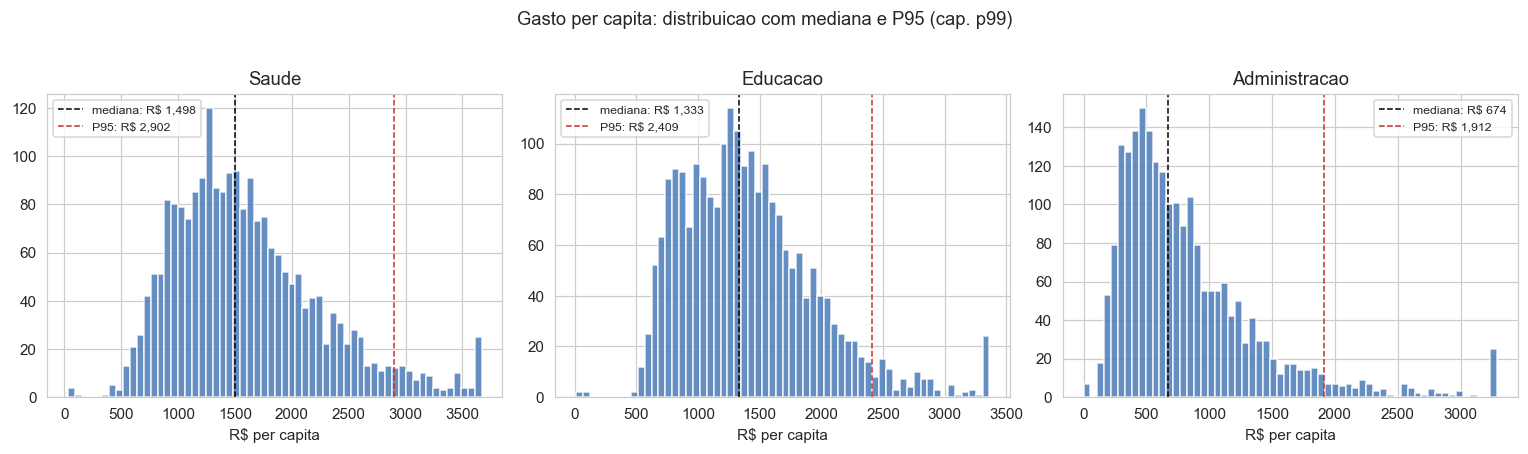

Features per capita: 29


In [159]:
PC_COLS = []
for f in COL_FUNCOES:
    c = f + '_pc'
    df[c] = df[f] / df['populacao'].clip(lower=1)
    PC_COLS.append(c)
df['total_pc'] = df['total_despesas'] / df['populacao'].clip(lower=1)

# Distribuicao das 3 funcoes mais relevantes
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, titulo in zip(
    axes,
    ['saude_pc', 'educacao_pc', 'administracao_pc'],
    ['Saude', 'Educacao', 'Administracao']):
    s = df[col].clip(upper=df[col].quantile(0.99))
    ax.hist(s, bins=60, color='#4a7ab8', alpha=0.85)
    ax.axvline(s.median(), color='black', ls='--', lw=1, label=f'mediana: R$ {s.median():,.0f}')
    ax.axvline(s.quantile(0.95), color='#c53030', ls='--', lw=1,
               label=f'P95: R$ {s.quantile(0.95):,.0f}')
    ax.set_title(titulo); ax.set_xlabel('R$ per capita')
    ax.legend(fontsize=8)
plt.suptitle('Gasto per capita: distribuicao com mediana e P95 (cap. p99)', y=1.02)
plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'fig_4_1_per_capita.png', bbox_inches='tight')
plt.show()
print(f'Features per capita: {len(PC_COLS)}')



### 4.2 — Proporção (`*_prop`)

> Pergunta: **Como distribuiu o orçamento?**

Para cada função, `valor / total_despesas`. Isso captura **perfil de
gasto** independente do tamanho do município. O gráfico abaixo mostra o
**perfil médio do PR** — onde tipicamente vai cada real gasto. Saúde,
educação e administração somam mais de 60% em quase todos os municípios.
Quem foge muito desse padrão chama atenção.

Os mínimos constitucionais são `saude ≥ 15%` e `educacao ≥ 25%`
(Lei Complementar 141/2012 e art. 212 da CF).



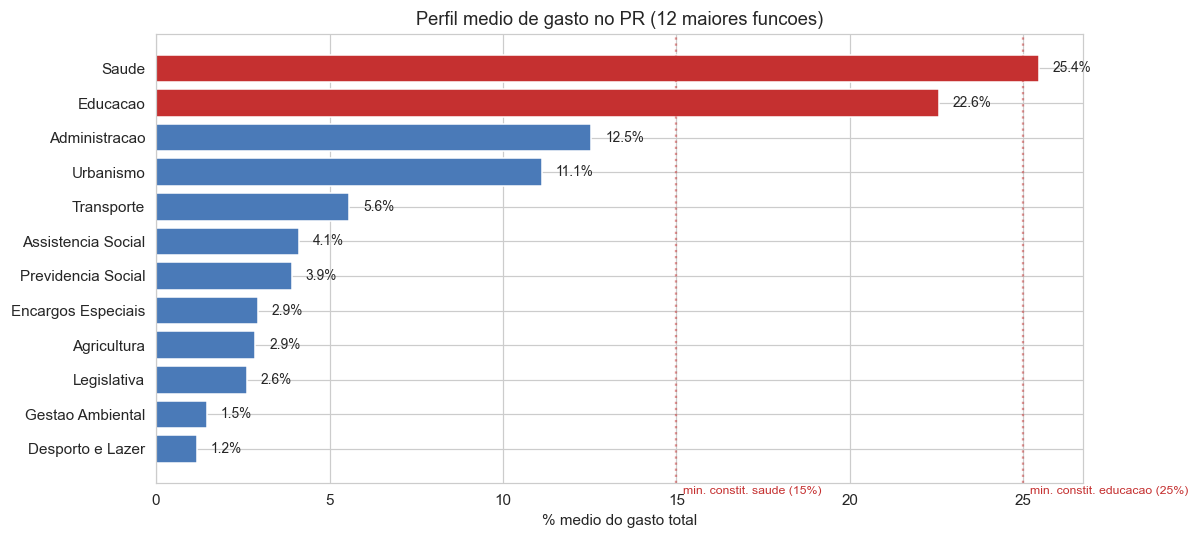

Features proporcao: 29


In [160]:
PROP_COLS = []
tot = df['total_despesas'].clip(lower=1)
for f in COL_FUNCOES:
    c = f + '_prop'
    df[c] = df[f] / tot
    PROP_COLS.append(c)

# Perfil medio do PR: barra horizontal das 12 maiores funcoes
medias = df[PROP_COLS].mean().sort_values(ascending=False).head(12)
labels = [LABELS_FUNCAO.get(c.replace('_prop', ''), c) for c in medias.index]
keys   = [c.replace('_prop', '') for c in medias.index]

fig, ax = plt.subplots(figsize=(11, 5))
cores = ['#c53030' if k in ('saude', 'educacao') else '#4a7ab8' for k in keys]
bars = ax.barh(range(len(labels)), medias.values * 100, color=cores)
for b, v in zip(bars, medias.values * 100):
    ax.text(v + 0.4, b.get_y() + b.get_height()/2, f'{v:.1f}%',
            va='center', fontsize=9)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel('% medio do gasto total')
ax.set_title('Perfil medio de gasto no PR (12 maiores funcoes)')
ax.axvline(15, color='#c53030', ls=':', alpha=0.5)
ax.axvline(25, color='#c53030', ls=':', alpha=0.5)
ax.text(15.2, 12.3, 'min. constit. saude (15%)', color='#c53030', fontsize=8)
ax.text(25.2, 12.3, 'min. constit. educacao (25%)', color='#c53030', fontsize=8)
plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'fig_4_2_proporcao.png', bbox_inches='tight')
plt.show()
print(f'Features proporcao: {len(PROP_COLS)}')



### 4.3 — Variação ano-a-ano (`*_var`)

> Pergunta: **Mudou bruscamente?**

Para cada função-chave: `(valor_ano - valor_ano_anterior) / valor_ano_anterior`.
Captura saltos: município que dobra o gasto em saúde de um ano pro outro
levanta suspeita, mesmo que o valor absoluto não seja extremo.

Calculamos para 6 funções: saúde, educação, administração, urbanismo,
assistência social, transporte. Valores são limitados a [-500%, +500%]
para que casos extremos não dominem a normalização.



In [161]:
df = df.sort_values(['cod_ibge', 'ano']).reset_index(drop=True)

FUNC_KEY = ['saude', 'educacao', 'administracao', 'urbanismo',
            'assistencia_social', 'transporte']
VAR_COLS = []
for f in FUNC_KEY:
    pc = f + '_pc'
    prev = df.groupby('cod_ibge')[pc].shift(1)
    var = (df[pc] - prev) / prev.replace(0, np.nan)
    df[f + '_var'] = var.clip(-5, 5).fillna(0.0)
    VAR_COLS.append(f + '_var')

# Quantos municipios-ano tem variacao > 100% em pelo menos 1 funcao?
extremos = (df[VAR_COLS].abs() > 1.0).any(axis=1).sum()
print(f'Features variacao: {len(VAR_COLS)}')
print(f'Linhas com pelo menos 1 funcao variando > 100% ano-a-ano: {extremos}'
      f' ({extremos/len(df)*100:.1f}%)')



Features variacao: 6
Linhas com pelo menos 1 funcao variando > 100% ano-a-ano: 460 (20.7%)


### 4.4 — Cluster de cidades parecidas

> Pergunta: **Quem é parecido com quem?**

Esta é a inovação metodológica do trabalho. Em vez de comparar todos os
municípios entre si (o que mistura Curitiba com cidade de 2 mil
habitantes), agrupamos primeiro por **similaridade de porte e perfil**
usando KMeans, e depois construímos features que medem o desvio de cada
município contra a **mediana do seu próprio cluster**.

Variáveis usadas no clustering:
- `log(populacao)` — porte demográfico
- `log(total_pc)` — porte do gasto per capita
- `saude_prop`, `educacao_prop`, `administracao_prop` — perfil de prioridades

Usamos **k = 5** clusters (heurística testada: 4 a 6 dão clusters
interpretáveis; mais que isso fragmenta sem ganhar informação). Sobre as
features padronizadas (`StandardScaler`) para que cada uma contribua
igualmente para a distância.



In [162]:
CLUSTER_FEATS = ['log_pop_cl', 'log_total_pc_cl',
                 'saude_prop_cl', 'educacao_prop_cl', 'administracao_prop_cl']
df['log_pop_cl']             = np.log1p(df['populacao'])
df['log_total_pc_cl']        = np.log1p(df['total_pc'])
df['saude_prop_cl']          = df['saude_prop']
df['educacao_prop_cl']       = df['educacao_prop']
df['administracao_prop_cl']  = df['administracao_prop']

cluster_X = StandardScaler().fit_transform(df[CLUSTER_FEATS].fillna(0))
K = 5
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
df['cluster'] = kmeans.fit_predict(cluster_X)

# Caracterizar cada cluster
print('Caracterizacao dos clusters:')
print('=' * 78)
caract = (df.groupby('cluster')
            .agg(n=('municipio', 'count'),
                 pop_med=('populacao', 'median'),
                 total_pc_med=('total_pc', 'median'),
                 saude_med=('saude_prop', 'median'),
                 educ_med=('educacao_prop', 'median'),
                 adm_med=('administracao_prop', 'median'))
            .round(3))
caract['pop_med']       = caract['pop_med'].astype(int)
caract['total_pc_med']  = caract['total_pc_med'].round(0).astype(int)
caract['saude_med']     = (caract['saude_med'] * 100).round(1).astype(str) + '%'
caract['educ_med']      = (caract['educ_med'] * 100).round(1).astype(str) + '%'
caract['adm_med']       = (caract['adm_med'] * 100).round(1).astype(str) + '%'
print(caract.to_string())



Caracterizacao dos clusters:
           n  pop_med  total_pc_med saude_med educ_med adm_med
cluster                                                       
0        455    11088          4640     31.2%    22.5%   11.0%
1        679    11425          5936     24.3%    23.9%   10.2%
2        352    46377          4050     24.5%    26.6%    8.9%
3        170     6409          5814     24.6%    22.1%   24.8%
4        570     4019          9622     23.3%    18.5%   12.2%


**Visualização dos clusters:** projetamos as 5 dimensões do clustering em
2D usando PCA. Cada ponto é um município-ano, colorido pelo cluster. Os
agrupamentos ficam visíveis: clusters separam por porte populacional
(direita-esquerda) e perfil de gasto (cima-baixo).



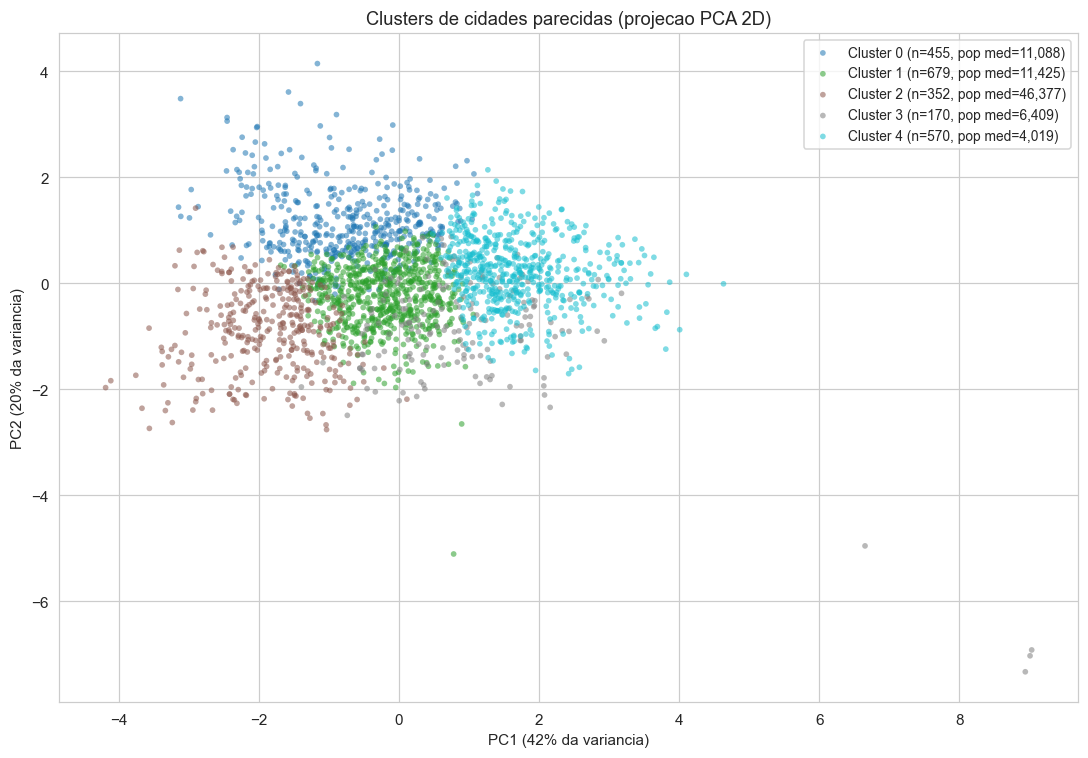

In [163]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
proj = pca.fit_transform(cluster_X)

fig, ax = plt.subplots(figsize=(10, 7))
cores = plt.cm.tab10(np.linspace(0, 1, K))
for k in range(K):
    mask = df['cluster'] == k
    n = mask.sum()
    pop_med = df.loc[mask, 'populacao'].median()
    label = f'Cluster {k} (n={n}, pop med={int(pop_med):,})'
    ax.scatter(proj[mask, 0], proj[mask, 1], s=14, alpha=0.55,
               color=cores[k], label=label, edgecolor='none')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% da variancia)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% da variancia)')
ax.set_title('Clusters de cidades parecidas (projecao PCA 2D)')
ax.legend(loc='best', fontsize=9)
plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'fig_4_4_clusters.png', bbox_inches='tight')
plt.show()



### 4.5 — Desvio em relação ao cluster (`*_dev`)

Agora que cada município tem um cluster, criamos features que medem
**quanto ele desvia da mediana do seu próprio cluster**. Isso é mais
informativo que comparar com a mediana global do PR, porque cidades
pequenas e grandes têm padrões de gasto naturalmente diferentes.

Para cada função-chave:

```
dev = (valor_pc - mediana_cluster_pc) / IQR_cluster_pc
```

Resultado: número de "IQRs de distância" da mediana do cluster. Valores
> 3 são fortemente atípicos *para aquele tipo de cidade*. Esta é a
feature mais interpretável do conjunto.



Top 10 maiores desvios em Saude vs mediana do cluster:
              Municipio  Ano  Cluster  Populacao  Saude (R$/hab)  Saude (desvio do cluster)
           Santa Helena 2025        1      26461         3079.75                       3.30
   Nova Aliança do Ivaí 2025        4       1322         4887.83                       3.23
              Miraselva 2022        3       1860         3455.28                       3.04
              Miraselva 2023        3       1934         3347.90                       2.89
  Rancho Alegre D'Oeste 2024        3       2638         3272.61                       2.77
          Jardim Olinda 2024        4       1353         4368.80                       2.60
              Araucária 2024        2     160038         2171.41                       2.59
          Jardim Olinda 2022        4       1324         4353.88                       2.59
                 Kaloré 2023        4       4437         4345.11                       2.58
Coronel Domingos Soares 2

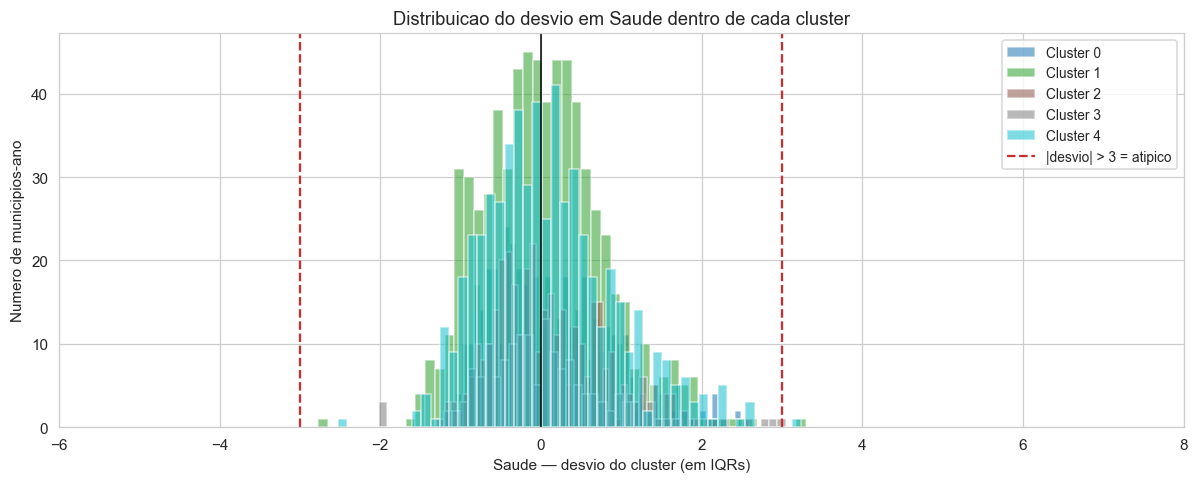


Features desvio do cluster: 6


In [164]:
DEV_COLS = []
for f in FUNC_KEY:
    pc = f + '_pc'
    grp = df.groupby('cluster')[pc]
    med = grp.transform('median')
    q1  = grp.transform(lambda s: s.quantile(0.25))
    q3  = grp.transform(lambda s: s.quantile(0.75))
    iqr = (q3 - q1).replace(0, np.nan)
    dev = (df[pc] - med) / iqr
    df[f + '_dev'] = dev.clip(-10, 10).fillna(0.0)
    DEV_COLS.append(f + '_dev')

# Top 10 maiores desvios em saude_pc (com rotulos amigaveis)
top_dev_saude = df.nlargest(10, 'saude_dev')[
    ['municipio', 'ano', 'cluster', 'populacao', 'saude_pc', 'saude_dev']].copy()
top_dev_saude.columns = ['Municipio', 'Ano', 'Cluster', 'Populacao',
                          'Saude (R$/hab)', 'Saude (desvio do cluster)']
print('Top 10 maiores desvios em Saude vs mediana do cluster:')
print(top_dev_saude.round(2).to_string(index=False))

# Grafico: distribuicao de saude_dev
fig, ax = plt.subplots(figsize=(11, 4.5))
for k in range(K):
    sub = df[df['cluster'] == k]['saude_dev']
    ax.hist(sub, bins=50, alpha=0.55, label=f'Cluster {k}', color=cores[k])
ax.axvline(0, color='black', lw=1)
ax.axvline(3, color='#c53030', ls='--', label='|desvio| > 3 = atipico')
ax.axvline(-3, color='#c53030', ls='--')
ax.set_xlabel('Saude — desvio do cluster (em IQRs)')
ax.set_ylabel('Numero de municipios-ano')
ax.set_title('Distribuicao do desvio em Saude dentro de cada cluster')
ax.set_xlim(-6, 8)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'fig_4_5_desvio.png', bbox_inches='tight')
plt.show()
print(f'\nFeatures desvio do cluster: {len(DEV_COLS)}')



### 4.6 — Contexto: porte e concentração

Duas variáveis que descrevem o município globalmente, e não uma função
específica.

#### `log_pop` — porte demográfico em escala logarítmica

A população dos municípios do PR varia de **~1.000 a ~2.000.000**
habitantes — três ordens de grandeza. Em escala linear, Curitiba sozinha
dominaria qualquer cálculo de distância (a diferença entre Curitiba e
Apucarana é mil vezes maior do que entre Apucarana e uma cidade pequena,
mesmo que essa última seja muito mais "parecida" com Apucarana do que
Curitiba).

A transformação `log(1 + pop)` comprime essa escala. Em log:
- Cidade de 1k hab → log_pop ≈ 6,9
- Cidade de 100k hab → log_pop ≈ 11,5
- Curitiba (~1,9M) → log_pop ≈ 14,5

Agora as distâncias ficam comparáveis e os algoritmos de densidade (LOF)
e particionamento (IF) tratam as cidades em pé de igualdade. **Sem isso,
LOF identificaria Curitiba como anômala apenas por ser grande**, sem
considerar o perfil de gasto.

#### `hhi` — concentração do gasto (Herfindahl-Hirschman Index)

```
hhi = soma( prop_funcao² )   para todas as 29 funções
```

É a soma dos quadrados das proporções de cada função no gasto total. Vai
de `1/29 ≈ 0.034` (gasto perfeitamente distribuído) até `1.0` (tudo numa
única função).

**Por que isso é informativo?** Um município que distribui o gasto entre
muitas funções (saúde, educação, urbanismo, saneamento, transporte...)
tem HHI baixo — perfil saudável. Quem concentra tudo em 2-3 funções
(tipicamente `administração` e `encargos especiais`, com pouco em saúde
e educação) tem HHI alto. Não é fraude por si só, mas é **sinal de
perfil enviesado** que merece atenção.

Exemplos típicos no dataset:
- HHI ≈ 0,12 → perfil distribuído, ~10 funções com peso similar
- HHI ≈ 0,25 → 4-5 funções dominam
- HHI ≈ 0,40+ → 2-3 funções concentram quase todo o gasto

A relação entre HHI e o score final é mostrada no gráfico abaixo.



In [165]:
df['log_pop'] = np.log1p(df['populacao'])
df['hhi']     = (df[PROP_COLS] ** 2).sum(axis=1)
CTX_COLS = ['log_pop', 'hhi']

FEATURES = PC_COLS + PROP_COLS + VAR_COLS + DEV_COLS + CTX_COLS
print(f'TOTAL DE FEATURES: {len(FEATURES)}')
print(f'  per_capita:         {len(PC_COLS)}')
print(f'  proporcao:          {len(PROP_COLS)}')
print(f'  variacao_aa:        {len(VAR_COLS)}')
print(f'  desvio_cluster:     {len(DEV_COLS)}')
print(f'  contexto:           {len(CTX_COLS)}')

print()
print('Estatisticas das features de contexto:')
print(df[['log_pop', 'hhi']].describe().round(3).to_string())



TOTAL DE FEATURES: 72
  per_capita:         29
  proporcao:          29
  variacao_aa:        6
  desvio_cluster:     6
  contexto:           2

Estatisticas das features de contexto:
        log_pop       hhi
count  2226.000  2226.000
mean      9.312     0.173
std       1.114     0.040
min       7.178     0.106
25%       8.504     0.153
50%       9.172     0.168
75%       9.848     0.188
max      14.490     0.972


### 4.7 — Como as 74 features alimentam Isolation Forest e LOF

As 5 famílias de features que construímos têm propósitos
complementares. Aqui mostramos como cada algoritmo "lê" o conjunto.

#### O espaço de busca

Cada município-ano vira um **ponto em 74 dimensões**. Cada eixo é uma
feature: `saude_pc`, `educacao_prop`, `saude_var`, `saude_dev`,
`log_pop`, `hhi`, etc. O dataset inteiro (2.227 municípios-ano) é uma
nuvem de pontos nesse espaço.

> **Anomalia = ponto distante do resto da nuvem em várias dimensões
> simultaneamente.**

Não basta ser extremo em uma dimensão. Um município pode ter `saude_pc`
alto porque é rico — isso não é anomalia. Mas se ele tem `saude_pc`
alto, `educacao_prop` baixo, `administracao_dev` muito alto e `hhi` em
nível incomum tudo ao mesmo tempo, **aí o ponto está em uma região
vazia do espaço** — é nisso que IF e LOF se concentram.

#### O papel de cada família

| Família | Eixos no espaço | Tipo de anomalia que captura |
|---|---|---|
| Per capita (29) | Valor absoluto por habitante | Cidade gastando muito ou muito pouco em uma função |
| Proporção (29) | Como divide o orçamento | Cidade com perfil de prioridades atípico |
| Variação (6) | Saltos ano-a-ano | Mudança brusca, possível obra/operação pontual |
| Desvio cluster (6) | Distância da mediana do grupo | Cidade atípica para o seu próprio porte |
| Contexto (4) | Porte e concentração | Calibra os outros eixos |

Sem proporção, perderíamos cidades pequenas com perfil enviesado.
Sem desvio_cluster, cidades pequenas com gasto naturalmente alto seriam
falsos positivos. Sem variação, fraudes pontuais (1 ano só) seriam
diluídas. **As famílias se complementam — nenhuma sozinha basta.**

#### Como Isolation Forest lê isso

IF constrói **árvores que dividem o espaço aleatoriamente**. Em cada
nó da árvore: escolhe uma feature ao acaso e um valor de corte ao
acaso, partindo o conjunto. Repete até cada ponto ficar isolado.

> **Ponto anômalo é isolado em poucas divisões.**

Imagine: se `educacao_prop` é 0,10 (típico ≈ 0,25), uma divisão aleatória
entre 0,05 e 0,15 já isola a maioria dos municípios atípicos. Quando
isso acontece em vários eixos simultaneamente, o ponto é isolado
rapidamente em qualquer caminho da árvore. **Profundidade média baixa →
score alto.**

IF é bom em **alta dimensão** porque cada feature contribui com chances
extras de isolamento rápido. Por isso ele tem peso 60% no ensemble.

#### Como LOF lê isso

LOF olha para a **densidade local**. Para cada ponto:
1. Encontra os k vizinhos mais próximos (k=20 aqui)
2. Calcula a densidade local desse ponto e a densidade média dos
   vizinhos
3. **Razão entre as duas densidades = LOF score**

Se um ponto está em região esparsa mas seus vizinhos estão em região
densa, LOF é alto. Captura **anomalias relativas**: ponto que é raro
*comparado aos seus vizinhos*, mesmo que não seja extremo no contexto
geral.

LOF complementa IF: às vezes uma anomalia não é "longe de tudo" (que
é o que IF pega), mas é "longe dos seus pares" (LOF). Por exemplo, uma
cidade pequena com gasto típico em 28 funções mas extremo em 1: IF pode
não isolar rápido, mas LOF detecta porque os 20 vizinhos mais próximos
não têm esse padrão.

#### Combinando os dois

```
score_final = 0.6 × IF + 0.4 × LOF
```

Quando os dois concordam (score IF alto **e** score LOF alto), a
anomalia é forte. Você verá no resultado final que muitas das top 20
têm scores parciais altos em ambos — isso é evidência de anomalia
robusta, detectada por **dois mecanismos independentes**.

Na seção 6 (depois da detecção) mostramos o "**raio-X de atipicidade**"
da anomalia #1: quais features dela estão nas caudas — ou seja, em
quantos eixos do espaço de 74 dimensões ela é extrema. Isso fecha o
ciclo: features → algoritmo → resultado interpretável.



## 5 — Normalização

`RobustScaler` (mediana + IQR). Robust em vez de Standard porque o
objetivo é **detectar** outliers — se a normalização usa média/desvio,
ela mesma é puxada pelos outliers e os esconde.



In [166]:
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(df[FEATURES])
scaler = RobustScaler()
X = scaler.fit_transform(X_imp)
print(f'X: {X.shape}  '
      f'(mediana={np.median(X):.3f}, IQR≈{np.percentile(X,75)-np.percentile(X,25):.3f})')



X: (2226, 72)  (mediana=0.000, IQR≈0.436)


## 6 — Detecção: Isolation Forest + LOF

**Isolation Forest** (Liu 2008): árvores aleatórias dividem o espaço;
pontos anômalos ficam isolados em poucas divisões. Bom para anomalias
**globais**.

**Local Outlier Factor** (Breunig 2000): compara densidade local com a
densidade dos vizinhos. Pega anomalias **locais** (ponto raro dentro
do seu grupo).

```
score = 0.6 × IF + 0.4 × LOF
```

IF tem peso maior por ser mais robusto em alta dimensão (74 features).

Classificação por percentil: `Critica ≥ P95`, `Suspeita ≥ P80`,
`Regular` no resto.



In [167]:
iso = IsolationForest(n_estimators=300, contamination='auto',
                      random_state=RANDOM_STATE, n_jobs=-1)
iso.fit(X)
if_raw  = -iso.score_samples(X)
if_norm = (if_raw - if_raw.min()) / (if_raw.max() - if_raw.min())

lof = LocalOutlierFactor(n_neighbors=20, contamination='auto', n_jobs=-1)
lof.fit_predict(X)
lof_raw  = -lof.negative_outlier_factor_
lof_norm = (lof_raw - lof_raw.min()) / (lof_raw.max() - lof_raw.min())

df['score_if']  = if_norm
df['score_lof'] = lof_norm
df['score']     = 0.6 * if_norm + 0.4 * lof_norm

p95 = df['score'].quantile(0.95)
p80 = df['score'].quantile(0.80)
df['classe'] = np.where(df['score'] >= p95, 'Critica',
                np.where(df['score'] >= p80, 'Suspeita', 'Regular'))

print(f'Cortes: P80 = {p80:.3f} · P95 = {p95:.3f}')
print(df['classe'].value_counts().to_string())



Cortes: P80 = 0.198 · P95 = 0.326
classe
Regular     1780
Suspeita     334
Critica      112


### 6.1 — Raio-X de atipicidade da anomalia #1

Pegamos o ponto com maior score e mostramos, em barras, **quanto ele se
desvia da mediana do dataset** em cada uma das features mais influentes.
Cada barra é uma feature; o comprimento é a distância do valor da
anomalia em relação à mediana, medida em IQRs (quartil-padrão).

Quanto mais barras compridas, mais "longe da nuvem" o ponto está, e por
isso ambos IF e LOF concordam que é anômalo. Esta visualização explica
**em quais eixos do espaço de 74 dimensões a anomalia se distingue**.



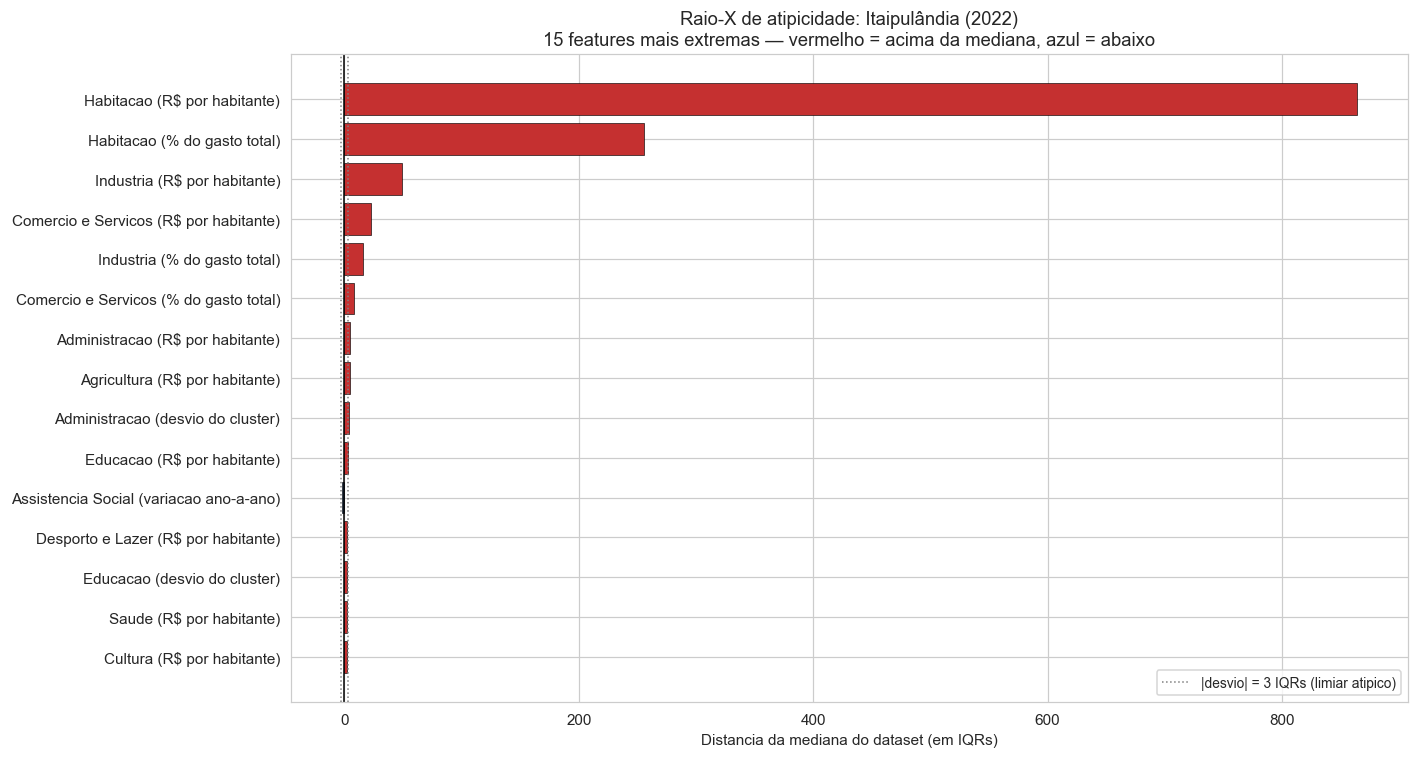


Itaipulândia (2022) tem score 0.694
  IF parcial:  0.891
  LOF parcial: 0.399
  Features com |desvio| > 3 IQRs: 10 de 72
  -> ponto distante da nuvem em 10 eixos simultaneamente,
     por isso ambos os algoritmos concordam que e anomalia.


In [168]:
top1_idx = df['score'].idxmax()
top1 = df.loc[top1_idx]

# Z-scores por IQR para todas features (relativo ao dataset)
medianas_glob = df[FEATURES].median()
q1_glob = df[FEATURES].quantile(0.25)
q3_glob = df[FEATURES].quantile(0.75)
iqr_glob = (q3_glob - q1_glob).replace(0, np.nan)
z_top1 = (top1[FEATURES] - medianas_glob) / iqr_glob

# Pegar as 15 features com maior |z|, traduzir nomes
top_z = z_top1.abs().sort_values(ascending=False).head(15)
nomes_tec = list(top_z.index)
nomes_amigaveis = [pretty(n) for n in nomes_tec]
valores = z_top1[nomes_tec].values

fig, ax = plt.subplots(figsize=(13, 7))
cores_b = ['#c53030' if v > 0 else '#2c5282' for v in valores]
y = range(len(nomes_amigaveis))
ax.barh(y, valores, color=cores_b, edgecolor='black', linewidth=0.4)
ax.set_yticks(y)
ax.set_yticklabels(nomes_amigaveis, fontsize=10)
ax.invert_yaxis()
ax.axvline(0, color='black', lw=1)
ax.axvline(3, color='gray', ls=':', lw=1, label='|desvio| = 3 IQRs (limiar atipico)')
ax.axvline(-3, color='gray', ls=':', lw=1)
ax.set_xlabel('Distancia da mediana do dataset (em IQRs)')
ax.set_title(f'Raio-X de atipicidade: {top1["municipio"]} ({top1["ano"]})\n'
             f'15 features mais extremas — vermelho = acima da mediana, azul = abaixo')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'fig_6_1_raio_x.png', bbox_inches='tight')
plt.show()

n_extremas = (z_top1.abs() > 3).sum()
print(f'\n{top1["municipio"]} ({top1["ano"]}) tem score {top1["score"]:.3f}')
print(f'  IF parcial:  {top1["score_if"]:.3f}')
print(f'  LOF parcial: {top1["score_lof"]:.3f}')
print(f'  Features com |desvio| > 3 IQRs: {n_extremas} de {len(FEATURES)}')
print(f'  -> ponto distante da nuvem em {n_extremas} eixos simultaneamente,')
print(f'     por isso ambos os algoritmos concordam que e anomalia.')



## 7 — Ranking e descrição das anomalias

Para cada anomalia crítica, o cartão mostra:
- **score** e **cluster** ao qual pertence
- comparação com a **mediana do cluster** (não só do PR)
- top 3 funções gastando **acima** dos pares (peers de pop. similar)
- top 3 funções gastando **abaixo**
- desvios em IQRs do cluster (`*_dev`) — quanto mais alto, mais atípico



In [169]:
def descrever(idx, n_pares=20):
    row = df.loc[idx]
    pool = df[(df['ano'] == row['ano']) & (df['classe'] == 'Regular') &
              (df.index != idx)].copy()
    pool['_d'] = (pool['populacao'] - row['populacao']).abs()
    pares = pool.nsmallest(n_pares, '_d')
    pc = [f + '_pc' for f in COL_FUNCOES]
    cent = pares[pc].mean()
    desv = {}
    for f, c, v in zip(COL_FUNCOES, cent.values, row[pc].values):
        if c > 0:
            desv[f] = (v - c) / c * 100
    acima  = sorted([(f, d) for f, d in desv.items() if d > 50], key=lambda x: -x[1])[:3]
    abaixo = sorted([(f, d) for f, d in desv.items() if d < -50], key=lambda x: x[1])[:3]
    return acima, abaixo


def imprimir(idx, rank):
    row = df.loc[idx]
    cluster = int(row['cluster'])
    cluster_pc_med = df[df['cluster'] == cluster]['total_pc'].median()
    razao_cluster = row['total_pc'] / cluster_pc_med if cluster_pc_med > 0 else 0
    razao_pr = row['total_pc'] / df['total_pc'].median()
    acima, abaixo = descrever(idx)

    print(f'\n#{rank:>2}  {row["municipio"]} ({row["ano"]})  '
          f'  score {row["score"]:.3f}  [{row["classe"]}]  cluster #{cluster}')
    print(f'      {row["populacao"]:>7,} hab  ·  '
          f'gasto total R$ {row["total_despesas"]/1e6:,.1f}M  ·  '
          f'R$ {row["total_pc"]:,.0f}/hab')
    print(f'      vs mediana PR:      {razao_pr:.1f}x'
          f'    ·    vs mediana cluster: {razao_cluster:.1f}x')
    print(f'      Saude: {row["saude_prop"]*100:5.1f}% (min 15%)  ·  '
          f'Educacao: {row["educacao_prop"]*100:5.1f}% (min 25%)')

    devs = [(f, row[f + '_dev']) for f in FUNC_KEY]
    devs_atip = [(f, d) for f, d in devs if abs(d) >= 3]
    if devs_atip:
        print(f'      Desvios atipicos no cluster (|desvio| >= 3 IQRs):')
        for f, d in sorted(devs_atip, key=lambda x: -abs(x[1])):
            print(f'        ! {LABELS_FUNCAO[f]:25s} desvio = {d:+.1f} IQRs')

    if acima:
        print(f'      Acima dos pares (mesmo ano, populacao similar):')
        for f, d in acima:
            print(f'        + {LABELS_FUNCAO[f]:25s} '
                  f'R$ {row[f+"_pc"]:>9,.0f}/hab  ({d:+.0f}%)')
    if abaixo:
        print(f'      Abaixo dos pares:')
        for f, d in abaixo:
            print(f'        - {LABELS_FUNCAO[f]:25s} '
                  f'R$ {row[f+"_pc"]:>9,.0f}/hab  ({d:+.0f}%)')


top20 = df[df['classe'] == 'Critica'].nlargest(20, 'score')
print('TOP 20 ANOMALIAS')
print('=' * 80)
for r, idx in enumerate(top20.index, 1):
    imprimir(idx, r)



TOP 20 ANOMALIAS

# 1  Itaipulândia (2022)    score 0.694  [Critica]  cluster #4
       11,720 hab  ·  gasto total R$ 198.5M  ·  R$ 16,938/hab
      vs mediana PR:      2.9x    ·    vs mediana cluster: 1.8x
      Saude:  17.5% (min 15%)  ·  Educacao:  20.4% (min 25%)
      Desvios atipicos no cluster (|desvio| >= 3 IQRs):
        ! Administracao             desvio = +4.0 IQRs
      Acima dos pares (mesmo ano, populacao similar):
        + Energia                   R$     1,319/hab  (+24604%)
        + Comercio e Servicos       R$       354/hab  (+2821%)
        + Industria                 R$     1,079/hab  (+2780%)
      Abaixo dos pares:
        - Judiciaria                R$         0/hab  (-100%)
        - Essencial a Justica       R$         0/hab  (-100%)
        - Defesa Nacional           R$         0/hab  (-100%)

# 2  Porto Rico (2023)    score 0.657  [Critica]  cluster #4
        3,062 hab  ·  gasto total R$ 46.5M  ·  R$ 15,180/hab
      vs mediana PR:      2.6x    ·    vs me

### Gráfico do ranking



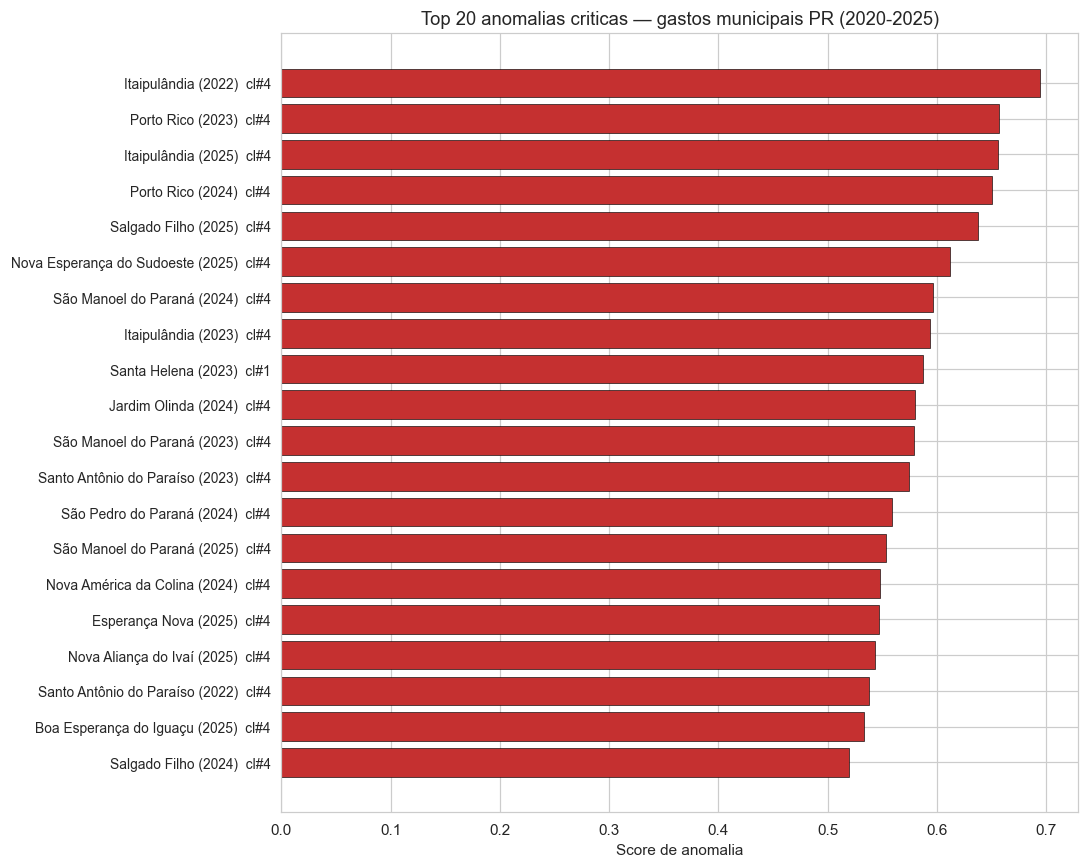

In [170]:
fig, ax = plt.subplots(figsize=(10, 8))
labels = [f'{m} ({a})  cl#{int(c)}' for m, a, c in
          zip(top20['municipio'], top20['ano'], top20['cluster'])]
ax.barh(range(len(top20)), top20['score'].values,
        color='#c53030', edgecolor='black', linewidth=0.4)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Score de anomalia')
ax.set_title('Top 20 anomalias criticas — gastos municipais PR (2020-2025)')
plt.tight_layout()
plt.savefig(EXPORTS_DIR / 'fig_7_ranking.png', bbox_inches='tight')
plt.show()



## 8 — Exportação



In [171]:
out_cols = (
    ['cod_ibge', 'municipio', 'ano', 'populacao', 'cluster',
     'total_despesas', 'total_pc']
    + ['saude', 'educacao', 'administracao']
    + ['saude_prop', 'educacao_prop', 'hhi']
    + [f + '_dev' for f in FUNC_KEY]
    + ['n_funcoes_declaradas', 'flag_negativo']
    + ['score_if', 'score_lof', 'score', 'classe']
)
out_cols = [c for c in out_cols if c in df.columns]

df[out_cols].to_csv(EXPORTS_DIR / 'gastos_com_score.csv', index=False)
df[df['classe'] != 'Regular'][out_cols] \
  .sort_values('score', ascending=False) \
  .to_csv(EXPORTS_DIR / 'gastos_anomalias.csv', index=False)

n_crit = (df['classe'] == 'Critica').sum()
n_susp = (df['classe'] == 'Suspeita').sum()
print(f'gastos_com_score.csv : {len(df):,} linhas')
print(f'gastos_anomalias.csv : {n_crit + n_susp:,} linhas')
print(f'\nFiguras geradas:')
for p in sorted(EXPORTS_DIR.glob('fig_*.png')):
    print(f'  {p.name}')
print(f'\nResumo: {n_crit} criticas + {n_susp} suspeitas em {len(df):,} municipio-ano')



gastos_com_score.csv : 2,226 linhas
gastos_anomalias.csv : 446 linhas

Figuras geradas:
  fig_4_1_per_capita.png
  fig_4_2_proporcao.png
  fig_4_4_clusters.png
  fig_4_5_desvio.png
  fig_6_1_raio_x.png
  fig_7_ranking.png

Resumo: 112 criticas + 334 suspeitas em 2,226 municipio-ano
